In [1]:
%%capture

import re

import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
%pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
%pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
%pip install --no-deps --upgrade "torchao>=0.16.0"
%pip install --no-deps transformers==5.5.0 "tokenizers>=0.22.0,<=0.23.0"
%pip install torchcodec

import torch; torch._dynamo.config.recompile_limit = 64;

%pip install --no-deps --upgrade timm  # For Gemma 4 vision/audio

%pip install evaluate rouge_score

import os
import gdown
import zipfile

## preprocessing

In [2]:
file_id = "1WhOgsEWmLSnEG2-K8R2n_hogFLGPkI8I"
download_url = f"https://drive.google.com/uc?id={file_id}"

zip_path = "/content/mredditsum.zip"
extract_dir = "/content/mredditsum_dataset"

# Download if not already downloaded
if not os.path.exists(zip_path):
    print("Downloading mRedditSum dataset...")
    gdown.download(download_url, zip_path, quiet=False)
else:
    print("ZIP file already exists. Skipping download.")

# Extract the ZIP file
if not os.path.exists(extract_dir):
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.")
else:
    print("Extracted folder already exists. Skipping extraction.")

print(f"Dataset extracted to: {extract_dir}")

Downloading...
From (original): https://drive.google.com/uc?id=1WhOgsEWmLSnEG2-K8R2n_hogFLGPkI8I
From (redirected): https://drive.google.com/uc?id=1WhOgsEWmLSnEG2-K8R2n_hogFLGPkI8I&confirm=t&uuid=7311d52e-dd7d-4af4-a1eb-50ea31e068fe
To: /content/mredditsum.zip
100%|██████████| 28.3M/28.3M [00:00<00:00, 65.4MB/s]


Extracting files...
Extraction complete.
Dataset extracted to: /content/mredditsum_dataset


In [3]:
from datasets import Dataset, DatasetDict
import json

data_dir = extract_dir
splits = {
    "train": {"src": "train_processed_src.txt", "tgt": "train_processed_tgt.txt", "raw": "train.json"},
    "val":   {"src": "val_processed_src.txt",   "tgt": "val_processed_tgt.txt", "raw": "val.json"},
    "test":  {"src": "test_processed_src.txt",  "tgt": "test_processed_tgt.txt", "raw": "test.json"},
}

dataset_dict = {}
for split_name, files in splits.items():
    src_path = os.path.join(data_dir + '/downloadable_data/preprocessed/', files["src"])
    tgt_path = os.path.join(data_dir + '/downloadable_data/preprocessed/', files["tgt"])
    raw_path = os.path.join(data_dir + '/downloadable_data/raw/', files["raw"])
    
    # Read source and target files line by line
    with open(src_path, "r", encoding="utf-8") as f:
        src_lines = f.read().strip().split("\n")
    with open(tgt_path, "r", encoding="utf-8") as f:
        tgt_lines = f.read().strip().split("\n")
    with open(raw_path, "r", encoding="utf-8") as f:
        raw_lines = json.load(f)["threads"]
        
    src_lines = [t[7:] for t in src_lines]
    tgt_lines = [t[7:] for t in tgt_lines]
    url_lines = [item["url"] for item in raw_lines]
    subreddit_lines = [item["subreddit"] for item in raw_lines]
    
    # Make sure we have matching pairs
    error_msg = f"Mismatch in {split_name}: {len(src_lines)} src vs {len(tgt_lines)} tgt vs raw {len(raw_lines)}"
    assert len(src_lines) == len(tgt_lines) == len(raw_lines) == len(url_lines) == len(subreddit_lines), error_msg
    
    # Create a Hugging Face Dataset for this split
    dataset_dict[split_name] = Dataset.from_dict({
        "source": src_lines,
        "target": tgt_lines,
        "url": url_lines,
        "subreddit": subreddit_lines
    })

# Combine into a single DatasetDict
mredditsum = DatasetDict(dataset_dict)
print(mredditsum)

DatasetDict({
    train: Dataset({
        features: ['source', 'target', 'url', 'subreddit'],
        num_rows: 2729
    })
    val: Dataset({
        features: ['source', 'target', 'url', 'subreddit'],
        num_rows: 152
    })
    test: Dataset({
        features: ['source', 'target', 'url', 'subreddit'],
        num_rows: 152
    })
})


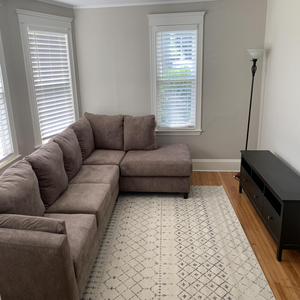

In [4]:
from PIL import Image
from io import BytesIO
import os
from IPython.display import display
import requests

def download_image(url):
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
    
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    
    img = Image.open(BytesIO(r.content))
    if img.mode != "RGB":
        img = img.convert("RGB")
    
    img = img.resize((300, 300), Image.Resampling.LANCZOS)
    
    return img

download_image(mredditsum['train'][0]['url'])

In [5]:
from unsloth.chat_templates import standardize_data_formats

train_ds = standardize_data_formats(mredditsum['train'])
val_ds = standardize_data_formats(mredditsum['val'])

train_ds[0]

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


{'source': "Original Post: Would you put the sectional on the other side?? OP: So I think I may have made this post confusing. What I would be doing is changing the side the chaise is on and putting the couch in the other side of the room. The side they are in now are bay windows and I feel I’m losing almost a foot of space. I understand that a tv with windows behind wouldn’t be ideal. But I don’t usually watch tv during the day anyway User 1: It sounds like you would be losing foot space regardless because the tv stand wouldn’t be able to fully fit in the bay window either. I think it looks nice as is. Maybe look into if there is a console table you could put behind the couch that is designed to fit with a bay window? OP: I’m getting a tv stand that is less wide to fit the space. User 2: Is there space to put a TV stand in the corner by the windows? User 3: You could put some tall plants behind the sofa or find a sofa table that fits between the couch and the windows? It’s hard to tel

In [6]:
from tqdm import tqdm

url2file = {}

for url in tqdm(list(train_ds['url']) + list(val_ds['url'])):
    try:
        image = download_image(url)
        url2file[url] = image
    except:
        continue

100%|██████████| 2881/2881 [12:51<00:00,  3.73it/s]  


In [7]:
print('before', len(train_ds), len(val_ds))

train_ds = train_ds.filter(lambda example: example["url"] in url2file)
val_ds = val_ds.filter(lambda example: example["url"] in url2file)

print('after', len(train_ds), len(val_ds))

before 2729 152


Filter:   0%|          | 0/2729 [00:00<?, ? examples/s]

Filter:   0%|          | 0/152 [00:00<?, ? examples/s]

after 2344 127


In [9]:
def formatting_prompts_func(example):
    messages = [
        {
            "role": "user",
            "content": [
                { "type": "image", "image": url2file[example["url"]] },
                {
                    "type" : "text",
                    "text" : f"Please write a summary of the following Reddit post from \"{example["subreddit"]}\" subreddit:\n{example["source"]}",
                }
            ]
        },
        {
            "role": "assistant",
            "content": [{
                "type" : "text",
                "text" : example["target"],
            }]
        },
    ]

    # remove bos for fine-tuning
    messages_tokenized = tokenizer.apply_chat_template(messages, tokenize = False, add_generation_prompt = False).removeprefix('<bos>')
    
    return { "text" : messages_tokenized }

train_ds = train_ds.map(formatting_prompts_func)
val_ds = val_ds.map(formatting_prompts_func)

train_ds[0]['text']

Map:   0%|          | 0/2344 [00:00<?, ? examples/s]

Map:   0%|          | 0/127 [00:00<?, ? examples/s]

'<|turn>user\n<|image|>Please write a summary of the following Reddit post from "designmyroom" subreddit:\nOriginal Post: Would you put the sectional on the other side?? OP: So I think I may have made this post confusing. What I would be doing is changing the side the chaise is on and putting the couch in the other side of the room. The side they are in now are bay windows and I feel I’m losing almost a foot of space. I understand that a tv with windows behind wouldn’t be ideal. But I don’t usually watch tv during the day anyway User 1: It sounds like you would be losing foot space regardless because the tv stand wouldn’t be able to fully fit in the bay window either. I think it looks nice as is. Maybe look into if there is a console table you could put behind the couch that is designed to fit with a bay window? OP: I’m getting a tv stand that is less wide to fit the space. User 2: Is there space to put a TV stand in the corner by the windows? User 3: You could put some tall plants beh

## train

In [23]:
from unsloth import FastModel

MODEL_NAME = 'unsloth/gemma-4-E2B-it'

model, tokenizer = FastModel.from_pretrained(
    model_name = MODEL_NAME,
    dtype = None,
    max_seq_length = 1024,
    load_in_4bit = True,
    full_finetuning = False,
)

==((====))==  Unsloth 2026.5.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

In [10]:
from transformers import TextStreamer

def do_gemma_4_inference(messages, max_new_tokens = 128, with_streamer = True):
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        tokenize = True,
        return_dict = True,
        return_tensors = "pt",
    ).to("cuda")
    
    if not with_streamer:
        return model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            temperature = 1.0, top_p = 0.95, top_k = 64, # recommended by devs
            use_cache = True
        ), inputs
    
    _ = model.generate(
        **inputs,
        max_new_tokens = max_new_tokens,
        temperature = 1.0, top_p = 0.95, top_k = 64, # recommended by devs
        streamer = TextStreamer(tokenizer, skip_prompt = True),
        use_cache = True
    )

In [20]:
import evaluate
from tqdm import tqdm

rouge = evaluate.load("rouge")
model.eval()

predictions, references = [], []

for example in tqdm(val_ds.select(range(len(val_ds))), desc="Generating summaries"):
    ref = example["target"]
    
    messages = [
        {
            "role": "user",
            "content": [
                { "type": "image", "image": url2file[example["url"]] },
                {
                    "type" : "text",
                    "text" : f"Please write a summary of the following Reddit post from \"{example["subreddit"]}\" subreddit:\n{example["source"]}",
                }
            ]
        }
    ]
    
    outputs, inputs = do_gemma_4_inference(messages, with_streamer=False)

    pred = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True
    ).strip()
    
    predictions.append(pred)
    references.append(ref)

results = rouge.compute(
    predictions=predictions,
    references=references,
    use_stemmer=True,
)

for k, v in results.items():
    print(f"  {k}: {v:.4f}")
    
print(predictions[0])
print(references[0])

Generating summaries:   0%|          | 0/127 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Generating summaries: 100%|██████████| 127/127 [34:44<00:00, 16.41s/it]


  rouge1: 0.3741
  rouge2: 0.0873
  rougeL: 0.2125
  rougeLsum: 0.2577
Here is a summary of the Reddit post from the r/designmyroom subreddit:

**The original poster (OP) is seeking advice on whether to switch the placement of their sectional sofa to gain more space, as the current configuration places the chaise section against bay windows, which they feel is losing valuable space.**

**Key Discussion Points and Advice:**

* **The Dilemma:** The OP is considering moving the couch to the other side of the room, but they are concerned about losing space and the potential issue of a TV being positioned near windows.
* **Counterarguments & Suggestions:**
    * Some users suggested that the
The OP wanted to know which wall they should place their sectional couch up against in their living room.  Most commenters agreed that the seating should stay by the windows.  One commenter said to get a smaller couch, but OP said they can't.


In [ ]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r = 8,           # Larger = higher accuracy, but might overfit
    lora_alpha = 8,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
)

In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_ds.take(500),
    eval_dataset = val_ds,
    args = SFTConfig(
        dataset_text_field = "text",
        
        per_device_train_batch_size = 16,
        gradient_accumulation_steps = 4,
        
        warmup_steps = 5,
        num_train_epochs = 1,
        learning_rate = 2e-4, # Reduce to 2e-5 for long training runs
        
        logging_steps=1,
        eval_strategy="steps",
        eval_steps=1,
        
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        report_to = "none",
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/500 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/127 [00:00<?, ? examples/s]

In [27]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|turn>user\n",
    response_part = "<|turn>model\n",
)

Map (num_proc=16):   0%|          | 0/500 [00:00<?, ? examples/s]

Filter (num_proc=16):   0%|          | 0/500 [00:00<?, ? examples/s]

Unsloth: Removed 163 out of 500 samples from train_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.


Map (num_proc=16):   0%|          | 0/127 [00:00<?, ? examples/s]

Filter (num_proc=16):   0%|          | 0/127 [00:00<?, ? examples/s]

Unsloth: Removed 43 out of 127 samples from eval_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.


In [28]:
tokenizer.decode(trainer.train_dataset[100]["input_ids"])

'<|turn>user\n<|image|>Please write a summary of the following Reddit post from "malelivingspace" subreddit:\nOriginal Post: What color of Bed Sheets will go with the color of my room? User 1: I’d suggest a dark red User 2: I find a lot about this room perplexing, if I’m honest.  But I think I would actually suggest blue, royal or a bright navy. Complete the primary color trifecta and it could have a sort of mod appeal to it.  EDIT: This is based on my initial viewing that those ceiling cabinets were yellow. On second glance, that may just be the lighting. User 3: What\'s wrong with the white that\'s already there? User 4: Navy User 5: Looks like a fancy prison cell User 6: are you in jail by any chance? OP: Why is everyone roasting my room 😭. Give me a break User 6: just a little banter. don\'t take it too hard! id say a few things kinda give it that vibe. the gray walls are a strong part of it for sure. the fact that its narrow as well, and that the windows seems black as if there ar

In [33]:
tokenizer.decode([tokenizer.pad_token_id if x == -100 else x for x in trainer.train_dataset[100]["labels"]]).replace(tokenizer.pad_token, "")

'The OP wanted advice on what color bed sheets to use in their bedroom with gray walls, a red ceiling fixture and black window at one end.  One commenter recommended dark red for the sheets.  Another commenter suggested different shades of dark blue. One suggested a range of colors including light blue, white, black, or dark olive green.  Another thought the current sheets looked fine.  One user gave reasons why the room looked similar to a jail cell, but gave the OP some encouragement and advice including adding folding towels on the bed.<turn|>\n'

In [34]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA A100-SXM4-80GB. Max memory = 79.251 GB.
22.793 GB of memory reserved.


In [35]:
# trainer_stats = trainer.train(resume_from_checkpoint = True) # if fail or keyboard interrupt
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 337 | Num Epochs = 1 | Total steps = 6
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 4 x 1) = 64
 "-____-"     Trainable parameters = 14,929,920 of 5,138,107,936 (0.29% trained)
Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Unsloth: Will smartly offload gradients to save VRAM!


/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bits

Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss


Unsloth: Not an error, but Gemma4ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


: 

: 

: 